## PM4Py Demo

Python library for all types of process mining tasks.

More information in the [official documentation](https://processintelligence.solutions/static/api/2.7.11/pm4py.html).

### Import of PM4Py Library

In [70]:
# Necessary imports for the remainder of the notebook
import pm4py
import pm4py.objects.petri_net.importer
import pandas as pd

pd.options.mode.chained_assignment = None  # default='warn', suppress warnings when importing logs from https://www.ocel-standard.org/event-logs/

### Importing the event log

In [82]:
ocel = pm4py.read_ocel2_sqlite("./ContainerLogistics.sqlite")

D:\Users\84533\anaconda3\Lib\site-packages\pm4py\objects\ocel\importer\sqlite\variants\ocel20.py:98: UserWarning: There are unsatisfied OCEL 2.0 constraints in the given relational database: ['const_23_foreign_key_event_type_specific']
  warnings.warn(


### General overview:

In [46]:
print(ocel)
ocel.get_extended_table()

Object-Centric Event Log (number of events: 35372, number of objects: 3320, number of activities: 14, number of object types: 4, events-objects relationships: 32886)
Activities occurrences: Counter({'Collect Goods': 10553, 'Load Truck': 10553, 'Pick Up Empty Container': 1995, 'Drive to Terminal': 1989, 'Weigh': 1989, 'Bring to Loading Bay': 1969, 'Load to Vehicle': 1966, 'Place in Stock': 1814, 'Register Customer Order': 600, 'Create Transport Document': 594, 'Book Vehicles': 594, 'Order Empty Containers': 593, 'Depart': 127, 'Reschedule Container': 36})
Object types occurrences (number of objects): Counter({'Container': 1999, 'Customer Order': 600, 'Transport Document': 594, 'Vehicle': 127})
Unique activities per object type: Counter({'Container': 10, 'Transport Document': 5, 'Vehicle': 4, 'Customer Order': 2})
Please use <THIS>.get_extended_table() to get a dataframe representation of the events related to the objects.


,ocel:eid,ocel:timestamp,ocel:activity,ocel:type:Customer Order,ocel:type:Transport Document,ocel:type:Vehicle,ocel:type:Container
0,reg_co1,2023-05-22 11:54:42+00:00,Register Customer Order,[co1],NaN,NaN,NaN
1,reg_co2,2023-05-22 18:33:30+00:00,Register Customer Order,[co2],NaN,NaN,NaN
2,create_td1,2023-05-23 08:22:17+00:00,Create Transport Document,[co2],[td1],NaN,NaN
3,book_vehs_td1,2023-05-23 10:05:16+00:00,Book Vehicles,NaN,[td1],"[vh1, vh4]",NaN
4,reg_co3,2023-05-23 12:14:57+00:00,Register Customer Order,[co3],NaN,NaN,NaN
...,...,...,...,...,...,...,...
35367,to_bay_cr1937,2024-08-21 14:54:34+00:00,Bring to Loading Bay,NaN,NaN,NaN,[cr1937]
35368,load_truck_hu10557,2024-08-21 14:57:48+00:00,Load Truck,NaN,NaN,NaN,[cr2018]
35369,collect_hu10544,2024-08-21 14:57:48+00:00,Collect Goods,NaN,NaN,NaN,NaN
35370,load_veh_cr1939,2024-08-21 16:16:39+00:00,Load to Vehicle,NaN,NaN,NaN,[cr1939]


### Investigate Objects and Events

In [117]:
import pandas as pd

# 先筛选 Container，并去掉 Weight 为 NaN 的行
containers = ocel.objects[ocel.objects['ocel:type'] == 'Container']

print(containers.head())

   ocel:oid  AmountofHandlingUnits Status Weight  AmountofGoods  \
0       cr2                    6.0   None   None            NaN   
5       cr3                    6.0   None   None            NaN   
10      cr4                    6.0   None   None            NaN   
15      cr7                    6.0   None   None            NaN   
20     cr14                    6.0   None   None            NaN   

    AmountofContainers DepartureDate  ocel:type  
0                  NaN           NaN  Container  
5                  NaN           NaN  Container  
10                 NaN           NaN  Container  
15                 NaN           NaN  Container  
20                 NaN           NaN  Container  


In [124]:
maxamount_units = containers[containers['AmountofHandlingUnits'] == containers['AmountofHandlingUnits'].max()]
minamount_units = containers[containers['AmountofHandlingUnits'] == containers['AmountofHandlingUnits'].min()]

maxamount_name = maxamount_units.iloc[0]['ocel:oid']
max_amount_units = maxamount_units.iloc[0]['AmountofHandlingUnits']

minamount_name = minamount_units.iloc[0]['ocel:oid']
min_amount_units = minamount_units.iloc[0]['AmountofHandlingUnits']

print(f'The max amount container is {maxamount_name} at a amount of {max_amount_units} t.\n')
print(f'The min amount container is {minamount_name} at a price of {min_amount_units} t.\n')


The max amount container is cr2 at a amount of 6.0 t.

The min amount container is cr24 at a price of 1.0 t.



### Discovering Process Models

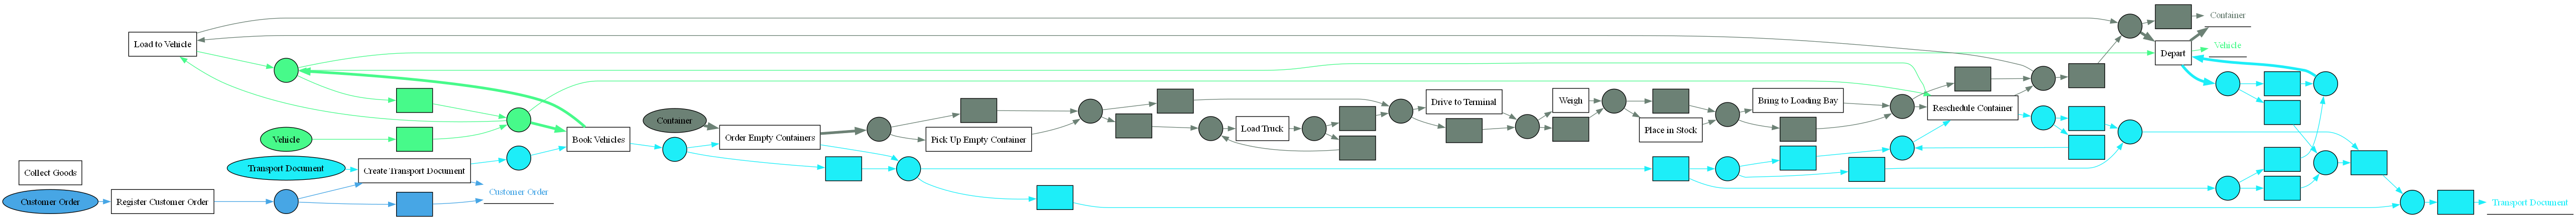

In [34]:
ocpn = pm4py.discover_oc_petri_net(ocel)
pm4py.view_ocpn(ocpn)

### Drill Down: Orders

In [126]:
event_log_orders = pm4py.ocel.ocel_flattening(ocel, "Customer Order")

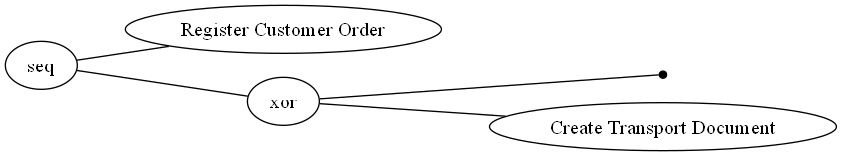

In [128]:
process_tree = pm4py.discover_process_tree_inductive(event_log_orders)
pm4py.view_process_tree(process_tree)

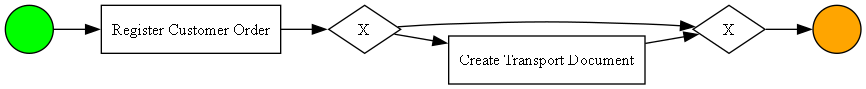

In [130]:
bpmn_model = pm4py.convert_to_bpmn(process_tree)
pm4py.view_bpmn(bpmn_model)